(1000, 9)
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


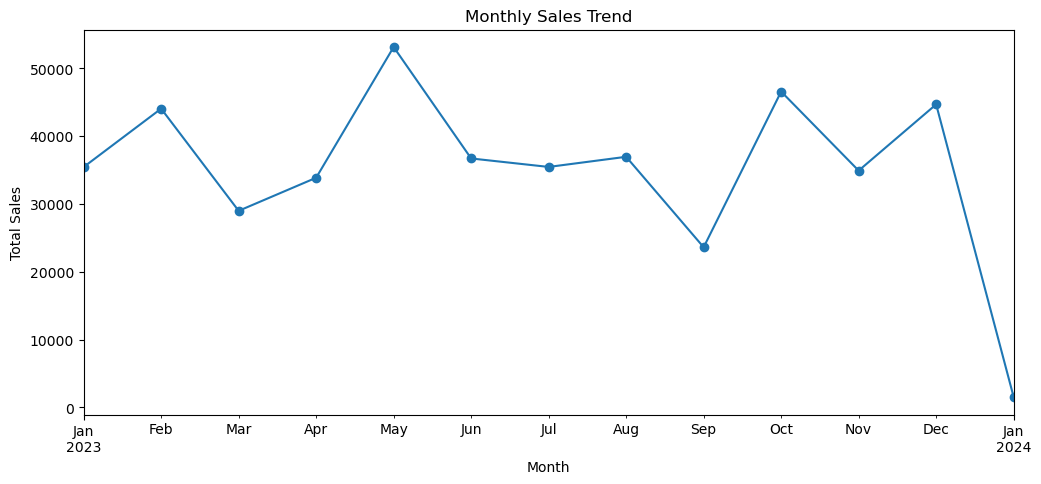

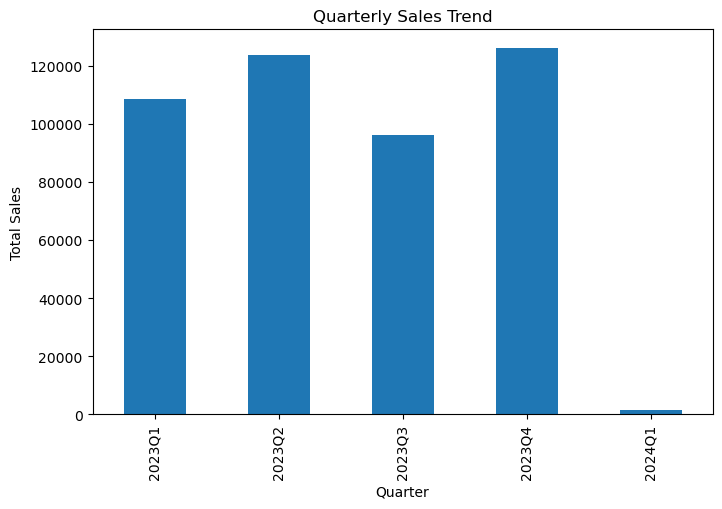

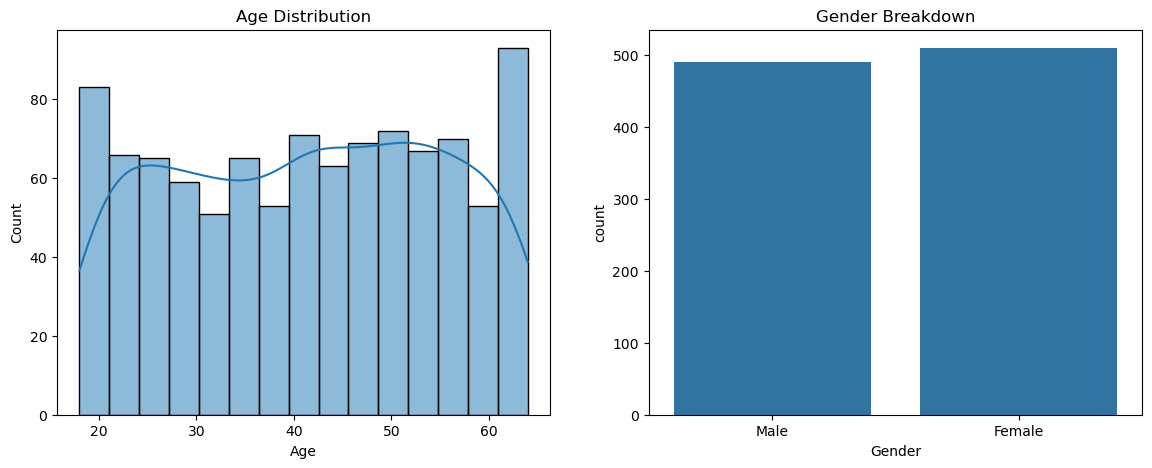

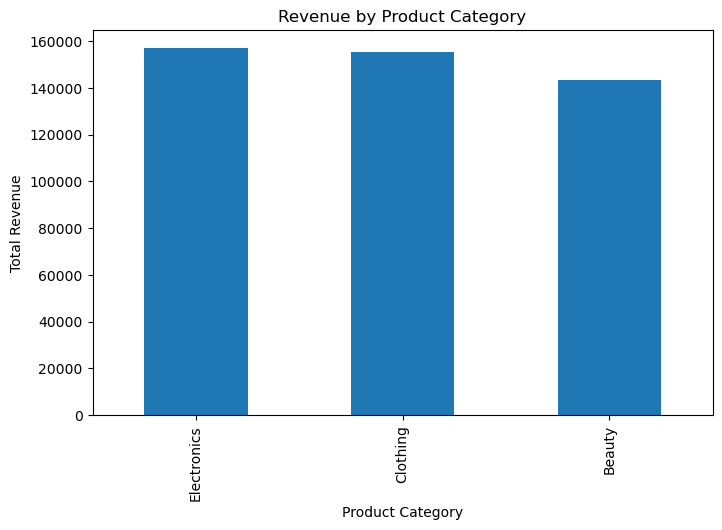

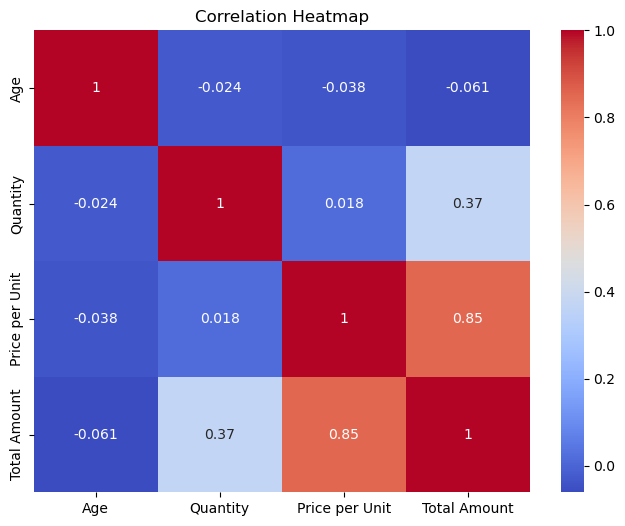

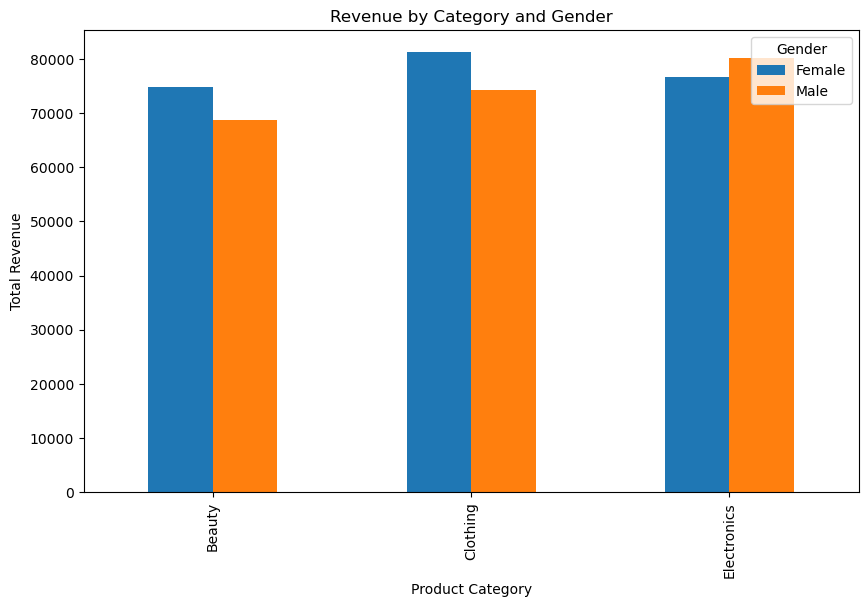

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/retail_sales_dataset.csv')
df.head()
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

df.describe()

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales.plot(kind='line', figsize=(12,5), title='Monthly Sales Trend', marker='o')
plt.ylabel('Total Sales')
plt.savefig('outputs/monthly_sales.png')
plt.show()

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()
quarterly_sales.plot(kind='bar', figsize=(8,5), title='Quarterly Sales Trend')
plt.ylabel('Total Sales')
plt.savefig('outputs/quarterly_sales.png')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['Age'], bins=15, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.countplot(data=df, x='Gender', ax=axes[1])
axes[1].set_title('Gender Breakdown')

plt.savefig('outputs/customer_demographics.png')
plt.show()

category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar', figsize=(8,5), title='Revenue by Product Category')
plt.ylabel('Total Revenue')
plt.savefig('outputs/category_revenue.png')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[['Age','Quantity','Price per Unit','Total Amount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('outputs/correlation_heatmap.png')
plt.show()

